In [2]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [3]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=250)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [4]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=250)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.name

'arxiv'

In [5]:
tools = [wiki, arxiv]

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import AzureOpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os
from dotenv import load_dotenv
load_dotenv("/home/abhi/AI_Workspace/personal/Generative-AI-Engineer-Portfolio/.env")

True

In [10]:
api_version = "2024-12-01-preview" 
embeddings = AzureOpenAIEmbeddings(
            model=os.getenv("AZURE_OPENAI_EMBEDDINGS_MODEL"),
            dimensions=1024,
            azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
            api_key=os.getenv("AZURE_OPENAI_API_KEY"),  
            openai_api_version=api_version
)

In [11]:
loader = WebBaseLoader("https://docs.langchain.com/langsmith/home")
docs = loader.load()
split_docs = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200).split_documents(docs)
vectorstore = FAISS.from_documents(split_docs, embeddings)
retriever = vectorstore.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x71375903bc10>, search_kwargs={})

In [12]:
from langchain_core.tools.retriever import create_retriever_tool
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="LangSmith_Docs_Retriever",
    description="Useful for answering questions about LangChain's LangSmith product and features. Use this tool to retrieve relevant information from the LangSmith documentation."
)

retriever_tool.name

'LangSmith_Docs_Retriever'

In [13]:
tools.append(retriever_tool)
tools

[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/home/abhi/.virtualenvs/my_genai_venv/lib/python3.11/site-packages/wikipedia/__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=250)),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=1, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=250)),
 StructuredTool(name='LangSmith_Docs_Retriever', description="Useful for answering questions about LangChain's LangSmith product and features. Use this tool to retrieve relevant information from the LangSmith documentation.", args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x713990362e80>, coroutine=<functio

In [15]:
from langchain_openai import AzureChatOpenAI
chat_model = AzureChatOpenAI(
            azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
            azure_deployment="gpt-5.2-chat",
            api_version="2025-04-01-preview",
            api_key=os.getenv("AZURE_OPENAI_API_KEY"),
            max_tokens=1024,
)

In [ ]:
'''
# This is deprecated. Now we need to access from LangSmith
from langchain import hub
prompt = hub.pull("hwchase17/openai-functions-agent")
'''
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
from langsmith import Client
client = Client()
prompt = client.pull_prompt("hwchase17/openai-functions-agent")
prompt.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

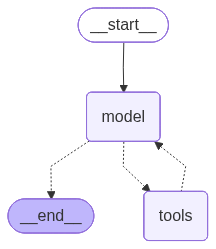

In [26]:
# create_agent in newer langchain versions only accepts system_prompt as string and not other placeholders.
# So the above prompt is not being used here.
from langchain.agents import create_agent
agent = create_agent(
    model = chat_model,
    tools = tools,
    system_prompt = "You are a helpful assistant"
)
agent

In [28]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "Explain LangSmith to me and find the research paper related to LangChain published on arXiv."}
    ]
})

In [29]:
response

{'messages': [HumanMessage(content='Explain LangSmith to me and find the research paper related to LangChain published on arXiv.', additional_kwargs={}, response_metadata={}, id='28466d67-56e2-4d82-ac83-cddeec3153f5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 319, 'total_tokens': 408, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-chat-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-D564bCCOOLzuVVXmQTnglImN8Wo7k', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severi